# Кредитный скоринг по анонимизированной кредитной истории

Исследование признаков и применение сохранённой модели LightGBM. Основная метрика — ROC-AUC, дополнительная — Average Precision. Определение и горизонт события `flag` не восстановлены из описания архива.

**Обычный запуск:** установи requirements.txt и выполни все ячейки. По умолчанию пропускается работа с сырым архивом, загружаются готовые веса и данные оценки. Никакого обучения нет.

**Полная подготовка:** скачай архив Kaggle, положи его в data/raw и включи RUN_RAW_ANALYSIS. Алгоритм первых разделов сохранён; изменены пути и управление запуском. Готовые базовые таблицы будут обновлены. Новое обучение находится в отдельном train_lightgbm.ipynb.

## 1. Окружение и режим запуска

Зависимости устанавливаются командой `python -m pip install -r requirements.txt` из корня проекта. Google Drive не требуется.

In [1]:
# Зависимости установлены из requirements.txt; во время анализа окружение не меняем.


In [2]:
from pathlib import Path
import sys

# Работаем из корня проекта или любой папки внутри него.
PROJECT_ROOT = next((p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
                     if (p / 'requirements.txt').is_file() and (p / 'src').is_dir()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Открой Jupyter внутри папки credit-scoring.')
sys.path.insert(0, str(PROJECT_ROOT))
RUN_RAW_ANALYSIS = False  # True: распаковка, EDA и базовые признаки; нужны сырые данные.
print('Проект:', PROJECT_ROOT)
print('Подготовка сырых данных:', RUN_RAW_ANALYSIS)


Проект: credit-scoring
Подготовка сырых данных: False


In [3]:
from pathlib import Path
import zipfile
import re
import gc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow.parquet as pq
from IPython.display import display

pd.set_option('display.max_columns', 70)
pd.set_option('display.max_colwidth', 140)
sns.set_theme(style='whitegrid')

In [4]:
ARCHIVE_PATH = PROJECT_ROOT / 'data/raw/alfa-bank-pd-credit-history.zip'
EXTRACT_DIR = PROJECT_ROOT / 'data/raw'
OUTPUT_DIR = PROJECT_ROOT / 'data/prepared'
MAX_TRAIN_APPLICATIONS = 100_000
MAX_TEST_APPLICATIONS = 25_000
BATCH_SIZE = 200_000
MAX_UNIQUE_TO_SHOW = 25
TOP_VALUES = 15
PREVIEW_ROWS = 5

## 2. Содержимое архива и распаковка
Повторный запуск не перезаписывает извлечённые файлы совпадающего размера. Если архив изменён, используй новую папку распаковки.

In [5]:
if RUN_RAW_ANALYSIS:
    if not ARCHIVE_PATH.is_file():
        raise FileNotFoundError(f'Не найден архив: {ARCHIVE_PATH.resolve()}. Укажи свой путь в ARCHIVE_PATH.')
    with zipfile.ZipFile(ARCHIVE_PATH) as archive:
        archive_inventory = pd.DataFrame([
            {'file': item.filename, 'size_MB': item.file_size / 1024**2,
             'compressed_MB': item.compress_size / 1024**2}
            for item in archive.infolist() if not item.is_dir()
        ])
    display(archive_inventory)
    print(f'Файлов: {len(archive_inventory)}')
    print(f'Размер после распаковки: {archive_inventory.size_MB.sum():.1f} MB')

In [6]:
if RUN_RAW_ANALYSIS:
    EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
    root = EXTRACT_DIR.resolve()
    with zipfile.ZipFile(ARCHIVE_PATH) as archive:
        for item in archive.infolist():
            destination = (root / item.filename).resolve()
            if not destination.is_relative_to(root):
                raise ValueError(f'Некорректный путь внутри ZIP: {item.filename}')
            if item.is_dir():
                continue
            if destination.exists() and destination.stat().st_size == item.file_size:
                continue
            archive.extract(item, root)
    print('Распаковано в:', root)

    candidates = list(root.rglob('train_target.csv'))
    if len(candidates) != 1:
        raise ValueError(f'Ожидался один train_target.csv, найдено: {len(candidates)}')
    DATA_DIR = candidates[0].parent

    def part_number(path):
        match = re.search(r'_(\d+)$', path.stem)
        return int(match.group(1)) if match else 0

    train_files = sorted((DATA_DIR / 'train_data').glob('*.pq'), key=part_number)
    test_files = sorted((DATA_DIR / 'test_data').glob('*.pq'), key=part_number)
    assert train_files and test_files, 'Не найдены Parquet-файлы кредитных историй'
    print('Корень данных:', DATA_DIR)
    print('Train-частей:', len(train_files), '| Test-частей:', len(test_files))

## 3. Словарь полей (description.xlsx)


In [7]:
if RUN_RAW_ANALYSIS:
    description_path = DATA_DIR / 'description.xlsx'
    with pd.ExcelFile(description_path) as book:
        descriptions = {sheet: pd.read_excel(book, sheet_name=sheet) for sheet in book.sheet_names}
    for sheet, frame in descriptions.items():
        print(f'Лист: {sheet}, размер: {frame.shape}')
        display(frame)

## 4. Таргет, тестовые заявки и пример submission
Эти CSV загружаются целиком. У test метки исхода могут отсутствовать — это не пропуски, которые нужно заполнять.

In [8]:
if RUN_RAW_ANALYSIS:
    train_target = pd.read_csv(DATA_DIR / 'train_target.csv')
    test_target = pd.read_csv(DATA_DIR / 'test_target.csv')
    sample_submission = pd.read_csv(DATA_DIR / 'sample_submission.csv')

    for name, frame in [('train_target', train_target), ('test_target', test_target),
                        ('sample_submission', sample_submission)]:
        print(f'\n{name}: {frame.shape}')
        frame.info()
        display(frame.head(PREVIEW_ROWS))
        display(pd.DataFrame({'dtype': frame.dtypes.astype(str),'missing': frame.isna().sum(), 'nunique': frame.nunique(dropna=True), 'dublicates': frame.duplicated().sum()}))
        print('='*70)
    print('В Submission те же ID, что test:', set(sample_submission.id) == set(test_target.id))

In [9]:
if RUN_RAW_ANALYSIS:
    target_distribution = train_target.flag.value_counts(dropna=False).rename('count').to_frame()
    target_distribution['share_%'] = target_distribution['count'] / len(train_target) * 100
    display(target_distribution)
    ax = target_distribution['count'].plot.bar(figsize=(6, 4), color=['#5276a7', '#d27a69'])
    ax.set(title='Распределение предоставленного таргета', xlabel='flag', ylabel='Заявок')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

## 5. Структура всех Parquet-частей
Читаем только метаданные: число строк, столбцов и схема. Строки здесь — кредитные продукты, а не независимые заявки.

In [10]:
if RUN_RAW_ANALYSIS:
    part_metadata = []
    reference_schema = pq.ParquetFile(train_files[0]).schema_arrow
    for split, paths in [('train', train_files), ('test', test_files)]:
        for path in paths:
            parquet = pq.ParquetFile(path)
            part_metadata.append({'split': split, 'file': path.name,'rows': parquet.metadata.num_rows,'columns': len(parquet.schema_arrow),
                                  'same_schema_as_first_train': parquet.schema_arrow.equals(reference_schema),'size_MB': path.stat().st_size / 1024**2})
    part_metadata = pd.DataFrame(part_metadata)
    display(part_metadata)
    display(part_metadata.groupby('split')[['rows', 'size_MB']].sum())


## 6. Подробный обзор первой train-части
Статистики этого раздела относятся только к указанному файлу. Он не является случайной репрезентативной выборкой всего train. Для всех частей предусмотрен отдельный аудит ниже.

In [11]:
if RUN_RAW_ANALYSIS:
    history_path = train_files[0]
    history = pd.read_parquet(history_path)
    print('Файл:', history_path.name, '| размер:', history.shape, '| Память:', round(history.memory_usage(deep=True).sum()/1024**2, 1), 'MB')
    display(history.head(PREVIEW_ROWS))
    history.info()

In [12]:
if RUN_RAW_ANALYSIS:
    column_summary = pd.DataFrame({'missing': history.isna().sum(),'missing_%': history.isna().mean() * 100,'nunique_without_NaN': history.nunique(dropna=True),})
    combined = (
        column_summary.join(history.describe(include='all').T).rename_axis('column').reset_index()
    )
    display(combined)

    print('Пропуски:', int(history.isna().sum().sum()))
    print('Повторы (id, rn) внутри файла:', int(history.duplicated(['id', 'rn']).sum()))

## 7. Распределения закодированных признаков (Сортируем по коду)

In [13]:
if RUN_RAW_ANALYSIS:

    feature_columns = [col for col in history.columns if col not in ['id', 'rn']]
    unique_counts = history[feature_columns].nunique().sort_values()
    code_columns = [col for col in feature_columns if col not in flag_columns]

    plots_per_row = 4
    n_rows = (len(code_columns) + plots_per_row - 1) // plots_per_row

    if code_columns:
        fig, axes = plt.subplots(
            n_rows, plots_per_row,
            figsize=(18, n_rows * 2.7),
            squeeze=False
        )

        for ax, column in zip(axes.flat, code_columns):
            series = history[column]
            shares = series.dropna().value_counts().sort_index() / len(history) * 100

            labels = [str(value) for value in shares.index]
            heights = shares.tolist()

            if series.isna().any():
                labels.append('NaN')
                heights.append(series.isna().mean() * 100)

            ax.bar(labels, heights, color='#5276a7', width=0.8)
            ax.set_title(column, fontsize=10)
            ax.set_ylabel('% строк', fontsize=8)
            ax.tick_params(axis='x', labelrotation=90, labelsize=7)
            ax.tick_params(axis='y', labelsize=8)
            ax.grid(axis='x', visible=False)
        for ax in list(axes.flat)[len(code_columns):]:
            ax.set_visible(False)

        fig.suptitle(
            f'Распределения исходных кодов: {history_path.name}',
            fontsize=14,
            y=1.002
        )
        plt.tight_layout()
        plt.show()

## 8. Кредитные продукты внутри заявки
Группировка ниже нужна только для описания структуры. Она не создаёт обучающие признаки и не меняет исходную таблицу.

In [14]:
if RUN_RAW_ANALYSIS:
    products_per_application = history.groupby('id').size()
    display(products_per_application.describe(percentiles=[.5, .9, .95, .99]).to_frame('credit_products'))
    example_ids = history.id.drop_duplicates().head(3)
    for application_id in example_ids:
        print('\nЗаявка:', application_id)
        display(train_target.loc[train_target.id.eq(application_id)])
        display(history.loc[history.id.eq(application_id)].head(10))

    ax = products_per_application.plot.hist(bins=40, figsize=(8, 4))
    ax.set(title=f'Кредитных продуктов на заявку: {history_path.name}',
           xlabel='Число продуктов', ylabel='Заявок')
    plt.tight_layout()
    plt.show()

## 9. Несколько распределений исходных кодов
Подписи сохраняют исходные имена. Графики показывают частоты кодов, а не восстановленные денежные суммы или сроки.

## 9. Выбираем заявки и сразу разделяем их по времени

В `description.xlsx` сказано: большему ID соответствует более поздняя дата заявки. Поэтому сортировка по ID даёт порядок во времени, но не конкретные календарные даты.

70% более ранних заявок — train, следующие 15% — validation, последние 15% — holdout. Validation нужен для выбора моделей и порога, holdout — для однократной итоговой оценки. Внешний test организаторов не имеет меток и остаётся отдельным.

Разбиваем **заявки**, а не строки кредитных продуктов. Иначе разные кредиты одной заявки попадут в разные части. ID заявки не равен ID человека: отсутствие одного клиента под разными заявками этим разбиением не гарантируется.

Равномерный выбор делаем без использования `flag`, чтобы сохранить покрытие всего временного порядка. Мы не обещаем одинаковую долю дефолтов в частях: её изменение само по себе полезно исследовать.

In [15]:
if RUN_RAW_ANALYSIS:
    def select_applications(target, maximum):
        ordered = target.sort_values('id').reset_index(drop=True)
        if maximum is None or maximum >= len(ordered):
            return ordered.copy()
        positions = np.linspace(0, len(ordered) - 1, maximum, dtype=int)
        return ordered.iloc[positions].reset_index(drop=True)

    selected_target = select_applications(train_target, MAX_TRAIN_APPLICATIONS)
    selected_test = select_applications(test_target, MAX_TEST_APPLICATIONS)
    n = len(selected_target)
    train_end, valid_end = int(n * 0.70), int(n * 0.85)
    train_labels = selected_target.iloc[:train_end].copy()
    valid_labels = selected_target.iloc[train_end:valid_end].copy()
    holdout_labels = selected_target.iloc[valid_end:].copy()

    split_overview = pd.DataFrame([
        {'split': name, 'applications': len(frame), 'min_id': frame.id.min(),
         'max_id': frame.id.max(), 'default_rate': frame.flag.mean()}
        for name, frame in [('train', train_labels), ('validation', valid_labels), ('holdout', holdout_labels)]
    ])
    display(split_overview)
    print('Внешний test: выбранных заявок', len(selected_test))

## 10. Загружаем истории выбранных заявок

Читаем файлы пакетами, оставляя строки нужных ID. Размер одного пакета ограничен `BATCH_SIZE`. Все оставленные строки собираются в память: пакетное чтение уменьшает пик чтения, но не делает весь дальнейший алгоритм потоковым.

Ничего не удаляем по «выбросам»: необычный код здесь может быть законной категорией. Пропуски не заполняем средним кодом — такой код не имеет числового смысла.

In [16]:
if RUN_RAW_ANALYSIS:
    def read_selected_history(paths, application_ids):
        wanted = np.asarray(application_ids)
        chunks = []
        for path in paths:
            rows_kept = 0
            for batch in pq.ParquetFile(path).iter_batches(batch_size=BATCH_SIZE):
                part = batch.to_pandas()
                selected = part.loc[part.id.isin(wanted)]
                if len(selected):
                    chunks.append(selected.copy())
                    rows_kept += len(selected)
            print(path.name, '| выбрано строк:', rows_kept)
        return pd.concat(chunks, ignore_index=True)

    # Освобождаем большой файл, использованный только для первичного обзора.
    del history
    gc.collect()
    selected_history = read_selected_history(train_files, selected_target.id)
    external_history = read_selected_history(test_files, selected_test.id)
    print('История выбранного train:', selected_history.shape)
    print('История выбранного внешнего test:', external_history.shape)

## 11. Какие признаки создаём и почему

| Группа | Пример | Обоснование |
|---|---|---|
| Объём истории | число кредитных продуктов | Это настоящее количество строк, а не сумма анонимных кодов |
| Разнообразие | число разных кодов типа кредита | Сравнение кодов на равенство сохраняет смысл |
| Флаги | доля продуктов без просрочек 90+ | Бинарные флаги расшифрованы в документации, их среднее имеет смысл |
| Частоты кодов | доля продуктов с кодом остатка долга 3 | Модель сама изучает связь интервала с риском; рубли мы не восстанавливаем |
| Последний продукт | исходные коды продукта с максимальным rn | По словарю большему rn соответствует более позднее открытие |
| Изменения статусов | доля соседних месяцев с разными кодами | Фиксирует нестабильность, но не доказывает ухудшение или просрочку |

Пример: три продукта имеют коды `[3, 3, 11]`. Доля кода 3 — `2/3`, кода 11 — `1/3`. Среднее `(3+3+11)/3` не рассчитываем.

Пример флагов: `[1, 0, 1]` в `is_zero_loans90` означает, что 2 из 3 продуктов не имели просрочек 90+.

Для частот выбираем ограниченный список финансовых и продуктовых полей. Все 25 платёжных месяцев по всем категориям сильно расширили бы таблицу; для начала используем позиции 0, 6, 12 и 24. Полные последовательности остаются для отдельного эксперимента.

**Не используем:** ID как признак, суммы/минимумы/максимумы кодов, отношения закодированных сумм, ручную «тяжесть» кодов статуса, SMOTE и масштабирование до обучения.

In [17]:
if RUN_RAW_ANALYSIS:
    code_columns = [col for col in selected_history.columns if col.startswith(('pre_', 'enc_'))]
    flag_columns = [col for col in selected_history.columns if col.startswith('is_zero_') or col in ['pclose_flag', 'fclose_flag']]
    payment_columns = sorted([col for col in selected_history if col.startswith('enc_paym_')],
                             key=lambda col: int(col.rsplit('_', 1)[1]))
    frequency_columns = [col for col in [
        'pre_since_opened', 'pre_loans_credit_limit', 'pre_loans_outstanding',
        'pre_loans_next_pay_summ', 'pre_loans3060', 'pre_loans6090', 'pre_loans90',
        'pre_util', 'enc_loans_credit_type', 'enc_loans_credit_status',
        'enc_loans_account_holder_type', 'enc_loans_account_cur',
        'enc_paym_0', 'enc_paym_6', 'enc_paym_12', 'enc_paym_24'
    ] if col in selected_history]

    # Словарь категорий изучаем только на train, без validation, holdout и test.
    # Неизвестные при применении категории попадут в отдельную долю unknown.
    train_history = selected_history.loc[selected_history.id.isin(train_labels.id)]
    category_vocabulary = {
        col: sorted(train_history[col].dropna().unique().tolist())
        for col in frequency_columns
    }
    display(pd.DataFrame({'field': frequency_columns,
                          'train_categories': [len(category_vocabulary[col]) for col in frequency_columns]}))
    del train_history
    gc.collect()

## 12. Функция подготовки: одна строка на заявку

Пропуски в исходных кодах учитываем отдельной долей. Если у заявки вообще нет истории, количество продуктов и доли выставляем в 0 и добавляем `has_history = 0`. Такое сочетание позволяет отличить отсутствие истории от наблюдавшейся нулевой доли.

Коды последнего продукта переводим в строки (`code_3`, `missing`), чтобы CatBoost воспринимал их как категории. Это изменение представления, а не восстановление исходных значений.

Доли соседних изменений включают любые различия кодов, в том числе служебные статусы: без расшифровки нельзя называть их ухудшением качества платежей.

In [18]:
if RUN_RAW_ANALYSIS:
    def make_application_features(raw, application_ids, vocabulary):
        groups = raw.groupby('id', sort=False)
        index = pd.Index(application_ids, name='id')
        features = pd.DataFrame(index=index)
        product_counts = groups.size()
        features['n_credit_products'] = product_counts.reindex(index, fill_value=0)
        features['has_history'] = (features.n_credit_products > 0).astype('int8')

        # Для кодов допустимо число различных категорий, но не среднее значение кода.
        diversity = groups[code_columns].nunique().add_suffix('__nunique')
        missing_share = raw[code_columns].isna().groupby(raw.id).mean().add_suffix('__missing_share')
        # Среднее бинарного флага = доля единиц; отдельно учитываем пропуски флагов.
        flag_share = groups[flag_columns].mean().add_suffix('__share')
        flag_missing = raw[flag_columns].isna().groupby(raw.id).mean().add_suffix('__missing_share')
        features = features.join([diversity, missing_share, flag_share, flag_missing])

        frequency_blocks = []
        for col, categories in vocabulary.items():
            counts = raw.groupby(['id', col]).size().unstack(col, fill_value=0)
            counts = counts.reindex(columns=categories, fill_value=0)
            shares = counts.div(product_counts, axis=0).fillna(0)
            shares.columns = [f'{col}__code_{value}_share' for value in categories]
            frequency_blocks.append(shares)
            unknown = raw[col].notna() & ~raw[col].isin(categories)
            unknown_share = unknown.groupby(raw.id).mean().rename(f'{col}__unknown_share')
            frequency_blocks.append(unknown_share.to_frame())
        features = features.join(frequency_blocks)

        # rn используется для выбора последнего продукта, но не попадает в X.
        latest = raw.sort_values(['id', 'rn']).drop_duplicates('id', keep='last').set_index('id')
        for col in code_columns + flag_columns:
            values = latest[col].reindex(index)
            features[f'latest__{col}'] = values.map(
                lambda value: 'missing' if pd.isna(value) else f'code_{value:g}'
            )

        # Сравниваем статусы на равенство. Номер категории не задаёт тяжесть события.
        payments = raw[payment_columns]
        left = payments.iloc[:, :-1].to_numpy()
        right = payments.iloc[:, 1:].to_numpy()
        observed = pd.notna(left) & pd.notna(right)
        comparisons = observed.sum(axis=1)
        changes = ((left != right) & observed).sum(axis=1)
        change_share = np.divide(changes, comparisons,
                                 out=np.full(len(raw), np.nan), where=comparisons > 0)
        changes_by_id = pd.Series(change_share, index=raw.index).groupby(raw.id)
        features['payment_change_share_mean'] = changes_by_id.mean()
        features['payment_change_share_max'] = changes_by_id.max()
        features['payment_pair_observed_share'] = pd.Series(
            observed.mean(axis=1), index=raw.index).groupby(raw.id).mean()

        numeric_columns = features.select_dtypes(include='number').columns
        # Ноль допустим для отсутствующих частот; NaN в среднем наблюдавшегося флага
        # (все значения пропущены) сохраняем для будущего train-only imputer.
        no_history = features.has_history.eq(0)
        features.loc[no_history, numeric_columns] = 0
        share_columns = [col for col in features if col.endswith('_share') and '__code_' in col]
        features[share_columns] = features[share_columns].fillna(0)
        features[numeric_columns] = features[numeric_columns].astype('float32')
        return features

    # Одна схема признаков применяется ко всем частям.
    all_features = make_application_features(selected_history, selected_target.id, category_vocabulary)
    external_features = make_application_features(external_history, selected_test.id, category_vocabulary)
    X_train = all_features.loc[train_labels.id].copy()
    X_valid = all_features.loc[valid_labels.id].copy()
    X_holdout = all_features.loc[holdout_labels.id].copy()
    y_train = train_labels.set_index('id').flag
    y_valid = valid_labels.set_index('id').flag
    y_holdout = holdout_labels.set_index('id').flag
    categorical_features = X_train.select_dtypes(include='object').columns.tolist()
    numerical_features = [col for col in X_train if col not in categorical_features]
    print('Train:', X_train.shape, '| validation:', X_valid.shape, '| holdout:', X_holdout.shape)
    print('Внешний test:', external_features.shape)
    print('Числовых признаков:', len(numerical_features), '| категориальных:', len(categorical_features))
    display(X_train.head())

## 13. Проверяем результат подготовки

Здесь только полезные проверки: размер таблицы, пропуски, распределения нескольких понятных признаков и неизвестные категории. Константные признаки пока не удаляем: если решим удалять, список определяем только по train и применяем ко всем частям.

Выбор словаря категорий зависит только от train. При будущей кросс-валидации внутри train его нужно заново строить внутри каждого обучающего фолда.

In [19]:
if RUN_RAW_ANALYSIS:
    display(X_train.dtypes.value_counts().to_frame('features'))
    display(X_train.isna().sum().loc[lambda values: values > 0].to_frame('missing_in_train'))
    display(X_train[['n_credit_products', 'has_history', 'payment_change_share_mean']].describe().T)
    print('Константных признаков на train:', int(X_train.nunique(dropna=False).eq(1).sum()))
    unknown_columns = [col for col in X_valid if col.endswith('__unknown_share')]
    display(pd.DataFrame({'validation_mean': X_valid[unknown_columns].mean(),
                          'holdout_mean': X_holdout[unknown_columns].mean(),
                          'external_test_mean': external_features[unknown_columns].mean()}))
    ax = X_train.n_credit_products.plot.hist(bins=40, figsize=(8, 4))
    ax.set(title='Train: количество кредитных продуктов на заявку', xlabel='Продуктов', ylabel='Заявок')
    plt.tight_layout()
    plt.show()

## 14. Сохраняем подготовленные таблицы

Parquet удобнее CSV: он сохраняет типы, занимает меньше места и быстрее читается. `flag` записываем рядом с признаками для удобства хранения, но при обучении обязательно отделяем его от X. ID сохраняем как идентификатор строки, а не признак модели.

В JSON сохраняем выбранные категории и настройки, чтобы новые заявки обрабатывались по той же схеме. Масштабирование и заполнение числовых пропусков оставляем внутри будущего пайплайна модели: обучать их до разбиения нельзя.

In [20]:
if RUN_RAW_ANALYSIS:
    import json
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    for name, features, labels in [
        ('train', X_train, y_train), ('validation', X_valid, y_valid), ('holdout', X_holdout, y_holdout)
    ]:
        prepared = features.copy()
        prepared['flag'] = labels
        prepared.reset_index().to_parquet(OUTPUT_DIR / f'{name}_features.parquet', index=False)
    external_features.reset_index().to_parquet(OUTPUT_DIR / 'external_test_features.parquet', index=False)
    settings = {
        'categorical_features': categorical_features,
        'numerical_features': numerical_features,
        'category_vocabulary': category_vocabulary,
        'max_train_applications': MAX_TRAIN_APPLICATIONS,
        'max_test_applications': MAX_TEST_APPLICATIONS,
        'split_by_ordered_id': [0.70, 0.15, 0.15],
        'target': 'flag as supplied by competition; horizon not verified in archive',
        'source': 'https://www.kaggle.com/competitions/alfa-bank-pd-credit-history'
    }
    with open(OUTPUT_DIR / 'feature_settings.json', 'w', encoding='utf-8') as file:
        json.dump(settings, file, ensure_ascii=False, indent=2,
                  default=lambda value: value.item() if isinstance(value, np.generic) else str(value))
    print('Сохранено в:', OUTPUT_DIR)
    print('Для CatBoost передадим categorical_features; для Logistic Regression сделаем отдельный train-only пайплайн.')

# Итоговая модель: LightGBM и сравнение экспериментов

Начало и подготовка данных сохранены без изменений. Этот раздел заменяет прежние ячейки обучения: **нового обучения здесь нет**. Используем сохранённые деревья, схему категорий и код построения признаков итогового эксперимента.

Цель — ранжирование риска `flag` для заявки по кредитной истории. Точное событие дефолта и горизонт 12 месяцев не подтверждены описанием архива: не приписываем их метке. Основная метрика — ROC-AUC, дополнительная — Average Precision (AP). Brier и log loss оценивают вероятности; доля выявленных дефолтов зависит от порога.

80% одобрений — выбранный учебный сценарий. Доходность, LGD и стоимость отказа отсутствуют, поэтому этот порог не называем экономически оптимальным. Holdout уже открыт: повторный запуск воспроизводит зафиксированную оценку.

## 15. Эксперименты и выбор итоговой модели

**Базовое сравнение.** На 70 тыс. заявок оценены Logistic Regression, Random Forest, CatBoost и LightGBM. История агрегирована до заявки; анонимные коды использованы как категории. Признаки описывают объём истории, частоты статусов и разнообразие продуктов.

**Масштабирование данных.** Рост train до 200 тыс. при прежних validation/holdout и словаре категорий повысил AUC регрессии с 0,7022 до 0,7166, CatBoost — с 0,7078 до 0,7222. Это подтвердило целесообразность расширения train.

**Поиск конфигурации.** На внутреннем разбиении проведены 6 экспериментов CatBoost и 10 LightGBM. Проверены гиперпараметры, расширенные признаки и веса классов. В проверенных вариантах балансировка не улучшила ранжирование. Выбран невзвешенный LightGBM как подходящее сочетание качества и скорости. На общей validation промежуточная модель с 500 тыс. train-заявок дала AUC 0,7350. Внутренние оценки поиска не смешиваются с этой validation.

**Итоговое обучение.** LightGBM обучен на 2 099 991 заявке до validation в порядке ID. Использованы нативные категории и NaN, счётчики флагов и агрегаты последних 3/5 кредитных продуктов. 600 итераций зафиксированы до внешней оценки; обучение заняло около 13,6 минуты. Validation: ROC-AUC 0,7450, AP 0,0943.

**Вероятности и политика.** Диагностическая sigmoid-калибровка на последовательных половинах validation не улучшила Brier/log loss на второй половине. Сохранены исходные score. Порог под 80% одобрений выбран на validation до открытия holdout.

**Итоговая проверка.** Holdout: ROC-AUC 0,7344, AP 0,0896. При фиксированном пороге одобрено 80,65% заявок, среди отказов оказались 48,1% событий. Риск среди одобренных — 2,15% против исходных 3,34%.

Результат характеризует улучшение решения в целом: одновременно менялись train и признаки. Полный CatBoost на том же train не проверяли. Holdout после этой проверки открыт; новые эксперименты будут отдельным этапом.

## 16. Загружаем обученную модель

`model.txt` содержит деревья и веса; `schema.json` — порядок признаков и категории. `inference.py` применяет эту схему. Старые таблицы `prepared_v2` не содержат дополнительных признаков итоговой модели: для validation берём сохранённую расширенную таблицу из папки эксперимента, для holdout — прогнозы выполненной проверки или тот же сохранённый построитель.

Пути соответствуют нашему завершённому запуску. Отчёт сохраняется отдельно, файлы модели не перезаписываются.

In [21]:
# Зависимости установлены из requirements.txt; во время анализа окружение не меняем.


In [22]:
from pathlib import Path
import json
import importlib.util
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss, log_loss
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, confusion_matrix
from IPython.display import display

FINAL_ROOT = PROJECT_ROOT
FINAL_RUN = PROJECT_ROOT / 'data/evaluation'
FINAL_MODEL_DIR = PROJECT_ROOT / 'models/lightgbm'
FINAL_REPORT_DIR = PROJECT_ROOT / 'reports/generated'
FINAL_REPORT_DIR.mkdir(parents=True, exist_ok=True)
FINAL_THRESHOLD = 0.053229853722525304  # Выбран по validation ДО открытия holdout.
REBUILD_HOLDOUT = False  # True: воспроизвести прогноз из сырой истории; обучения нет.

def final_load_module(name, path):
    spec = importlib.util.spec_from_file_location(name, path)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module

final_inference = final_load_module('portfolio_inference', PROJECT_ROOT / 'src/inference.py')
final_booster, final_schema = final_inference.load_model(FINAL_MODEL_DIR)
with open(FINAL_MODEL_DIR / 'metadata.json', encoding='utf-8') as file:
    final_metadata = json.load(file)
with open(FINAL_MODEL_DIR / 'split_manifest.json', encoding='utf-8') as file:
    final_manifest = json.load(file)
assert final_metadata['fit_completed']
assert final_booster.current_iteration() == final_metadata['actual_iterations'] == 600
print('Загружен LightGBM:', final_metadata['train_rows'], 'train,', final_booster.current_iteration(), 'деревьев')
display(pd.Series(final_metadata['parameters'], name='Параметры').to_frame())

Загружен LightGBM: 2099991 train, 600 деревьев


,Параметры
objective,binary
metric,"[auc, binary_logloss]"
learning_rate,0.05
num_leaves,31
min_data_in_leaf,100
lambda_l2,3.0
feature_fraction,0.9
scale_pos_weight,1.0
max_bin,63
min_data_in_bin,5


## 17. Воспроизводим validation и подключаем проверку holdout

На validation заново считаем прогноз сохранённого Booster и сравниваем его с экспортом обучения. На holdout по умолчанию читаем результаты уже проведённой проверки — повторно сканировать исходные части не требуется. При необходимости `REBUILD_HOLDOUT = True` воспроизводит подготовку и прогноз. Метки берём по сохранённым ID, порог не пересчитываем.

Проверки здесь защищают от смешивания версий признаков и разбиений.

In [23]:
final_valid = pd.read_parquet(FINAL_RUN / 'validation_predictions.parquet')
final_valid_features = pd.read_parquet(FINAL_RUN / 'validation_features.parquet').set_index('id')
final_valid_matrix = final_inference.encode_prepared(
    final_valid_features.loc[final_valid.id, final_schema['feature_columns']], final_schema)
final_valid_scores = final_booster.predict(final_valid_matrix)
np.testing.assert_allclose(final_valid_scores, final_valid.model_probability, rtol=1e-6, atol=1e-8)
np.testing.assert_array_equal(final_valid_features.loc[final_valid.id, 'flag'], final_valid.flag)
final_valid['model_probability'] = final_valid_scores

# Выбираем последний завершённый экспорт проверки, а не пустую папку запуска.
final_holdout_files = sorted(FINAL_RUN.glob('holdout_predictions.parquet'))
if final_holdout_files and not REBUILD_HOLDOUT:
    final_holdout = pd.read_parquet(final_holdout_files[-1])
    print('Holdout из:', final_holdout_files[-1])
else:
    import pyarrow.dataset as ds
    final_builder = final_load_module('portfolio_feature_builder', PROJECT_ROOT / 'src/feature_builder.py')
    with open(FINAL_MODEL_DIR / 'feature_settings.json', encoding='utf-8') as file:
        final_settings = json.load(file)
    final_ids = pd.read_csv(FINAL_RUN / 'holdout_ids.csv').id.to_numpy()
    final_labels = pd.read_csv(FINAL_RUN / 'holdout_labels.csv').set_index('id').flag.loc[final_ids]
    final_paths = sorted(str(p) for p in (PROJECT_ROOT / 'data/raw/data_for_competition/train_data').glob('*.pq'))
    final_dataset = ds.dataset(final_paths, format='parquet')
    final_batches = final_dataset.scanner(filter=ds.field('id').isin(final_ids.tolist()), batch_size=100_000)
    final_parts = [b.to_pandas() for b in final_batches.to_batches() if b.num_rows]
    final_raw = pd.concat(final_parts, ignore_index=True) if final_parts else final_dataset.head(0).to_pandas()
    final_features = final_builder.make_application_features(final_raw, final_ids, final_settings['category_vocabulary'])
    final_scores = final_booster.predict(final_inference.encode_prepared(final_features, final_schema))
    final_holdout = pd.DataFrame({'id': final_ids, 'flag': final_labels.to_numpy(), 'model_probability': final_scores})
    del final_raw, final_parts, final_features

for split_name, frame in [('validation', final_valid), ('holdout', final_holdout)]:
    assert frame.id.is_unique
    actual_hash = hashlib.sha256(np.sort(frame.id.to_numpy(dtype='int64')).tobytes()).hexdigest()
    assert actual_hash == final_manifest['id_hashes'][split_name], 'Разбиение отличается от итогового эксперимента'
    assert frame.flag.isin([0, 1]).all() and np.isfinite(frame.model_probability).all()
    assert frame.model_probability.between(0, 1).all()
    expected_labels = pd.read_csv(FINAL_RUN / f'{split_name}_labels.csv').set_index('id').flag
    np.testing.assert_array_equal(frame.flag, expected_labels.loc[frame.id])
    frame['approved'] = frame.model_probability < FINAL_THRESHOLD
    frame.to_parquet(FINAL_REPORT_DIR / f'{split_name}_predictions.parquet', index=False)
assert set(final_valid.id).isdisjoint(final_holdout.id)
print('Validation и holdout соответствуют сохранённому разбиению.')

Holdout из: credit-scoring/data/evaluation/holdout_predictions.parquet
Validation и holdout соответствуют сохранённому разбиению.


## 18. Итоговые метрики и фиксированная политика

Риск ниже порога → одобрение, выше или равен → отказ. «Выявленные дефолты» здесь — доля фактических `flag=1`, оказавшихся среди отклонённых заявок. Это не утверждение, что реальные дефолты удалось предотвратить.

In [24]:
def final_evaluate(frame, threshold=FINAL_THRESHOLD):
    y = frame.flag.to_numpy()
    p = frame.model_probability.to_numpy()
    approved = p < threshold
    return {
        'rows': len(y), 'defaults': int(y.sum()), 'overall_default_rate': y.mean(),
        'roc_auc': roc_auc_score(y, p), 'average_precision': average_precision_score(y, p),
        'brier_score': brier_score_loss(y, p), 'log_loss': log_loss(y, p, labels=[0, 1]),
        'approval_rate': approved.mean(), 'approved_count': int(approved.sum()),
        'default_rate_approved': y[approved].mean() if approved.any() else np.nan,
        'defaults_approved': int(y[approved].sum()), 'defaults_rejected': int(y[~approved].sum()),
        'good_rejected': int(((y == 0) & ~approved).sum()),
        'share_defaults_rejected': y[~approved].sum() / y.sum()
    }
final_metrics = pd.DataFrame({'validation': final_evaluate(final_valid), 'holdout': final_evaluate(final_holdout)})
display(final_metrics.round(6))
final_metrics.to_csv(FINAL_REPORT_DIR / 'lightgbm_validation_vs_holdout.csv')
final_confusion = pd.DataFrame(confusion_matrix(final_holdout.flag, (~final_holdout.approved).astype(int), labels=[0, 1]),
    index=['Без дефолта', 'Дефолт'], columns=['Одобрено', 'Отказ'])
display(final_confusion)
final_confusion.to_csv(FINAL_REPORT_DIR / 'holdout_confusion_matrix.csv')

,validation,holdout
rows,15000.000000,15000.000000
defaults,530.000000,501.000000
overall_default_rate,0.035333,0.033400
roc_auc,0.745034,0.734377
average_precision,0.094264,0.089613
brier_score,0.033178,0.031506
log_loss,0.139773,0.134940
approval_rate,0.800000,0.806467
approved_count,12000.000000,12097.000000
default_rate_approved,0.022417,0.021493


,Одобрено,Отказ
Без дефолта,11837,2662
Дефолт,260,241


## 19. По одному представителю каждого семейства

Сравниваем выбранные сохранённые решения на общей validation: Logistic Regression и CatBoost на 200 тыс., Random Forest на 70 тыс. и итоговый LightGBM на 2,1 млн. Метрики всех моделей пересчитываются из сохранённых прогнозов; ID и метки сверяются.

У каждого baseline порог выбирался на validation под 80% одобрений. Отличаются объёмы train и признаки: таблица не является чистым сравнением алгоритмов. Проверка holdout относится только к итоговому LightGBM.

,train_rows,roc_auc,average_precision,brier_score,log_loss,approval_rate,default_rate_approved,share_defaults_rejected,source
model,,,,,,,,,
LightGBM (итоговый),2099991,0.745034,0.094264,0.033178,0.139773,0.8,0.022417,0.492453,Прогноз загруженного Booster
CatBoost,200000,0.722212,0.088480,0.033316,0.142095,0.8,0.024083,0.454717,Сохранённые validation-прогнозы
Logistic Regression,200000,0.716588,0.080180,0.033678,0.143552,0.8,0.024167,0.452830,Сохранённые validation-прогнозы
Random Forest,70000,0.692075,0.076371,0.033491,0.144930,0.8,0.026500,0.400000,Сохранённые validation-прогнозы


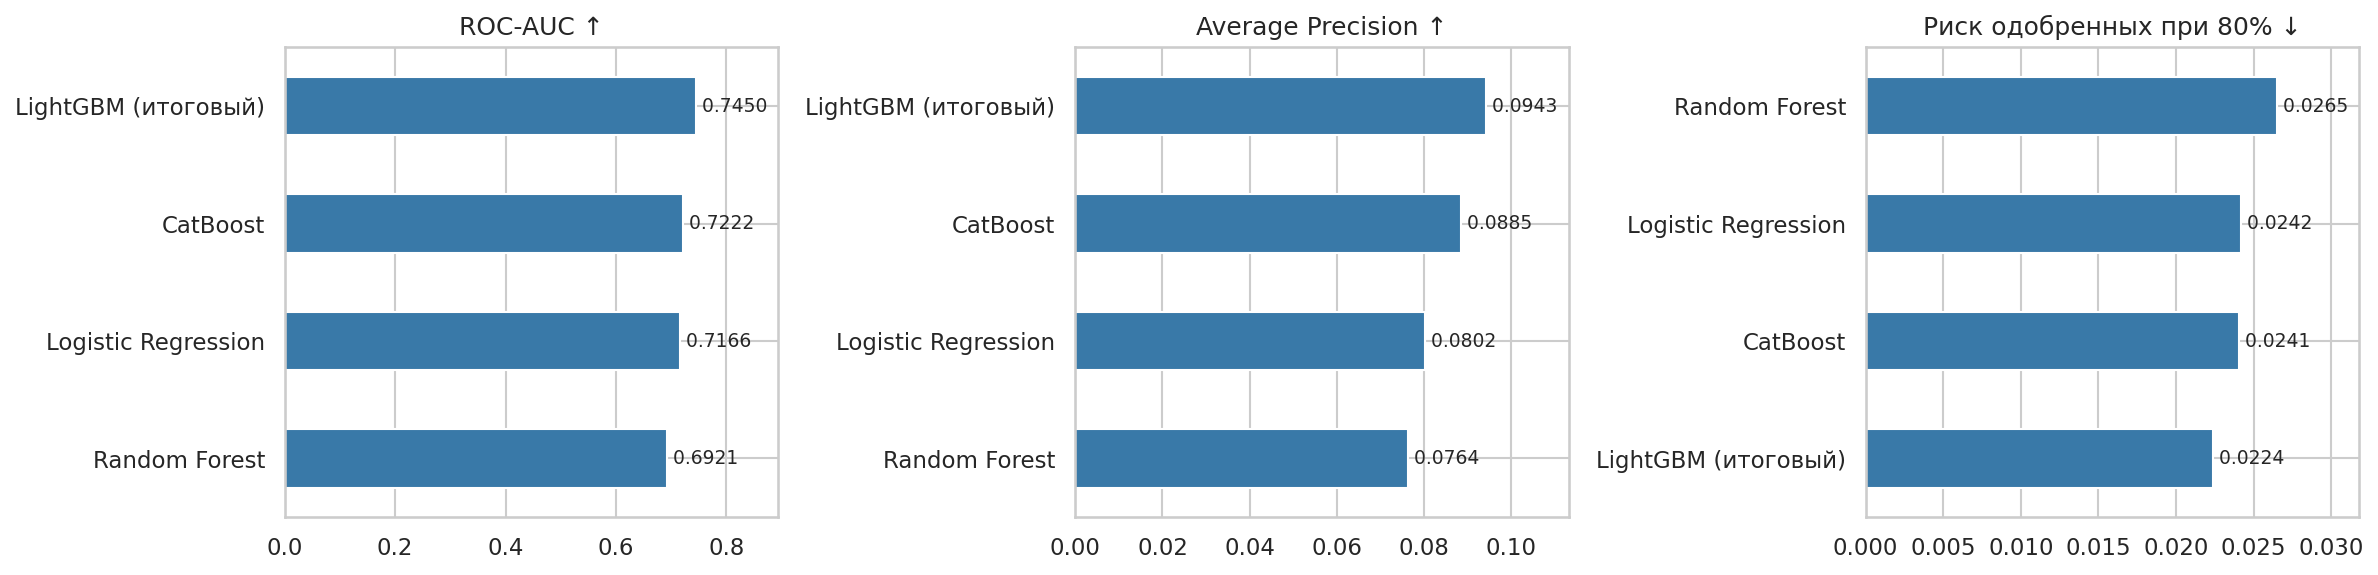

In [25]:
# Пересчитываем baseline-метрики, не загружая старые pickle-модели.
final_rows = []
for name, filename, train_rows in [
    ('Logistic Regression', 'logistic_regression', 200000),
    ('Random Forest', 'random_forest', 70000),
    ('CatBoost', 'catboost', 200000),
]:
    frame = pd.read_parquet(FINAL_RUN / 'baselines' / f'{filename}_validation_predictions.parquet')
    assert frame.id.is_unique and set(frame.id) == set(final_valid.id)
    frame = frame.set_index('id').loc[final_valid.id].reset_index()
    np.testing.assert_array_equal(frame.flag, final_valid.flag)
    frame = frame.rename(columns={'default_probability': 'model_probability'})
    threshold = float(np.quantile(frame.model_probability, 0.80))
    scores = final_evaluate(frame, threshold)
    final_rows.append({'model': name, 'train_rows': train_rows,
                      **{key: scores[key] for key in ['roc_auc', 'average_precision', 'brier_score',
                         'log_loss', 'approval_rate', 'default_rate_approved', 'share_defaults_rejected']},
                      'source': 'Сохранённые validation-прогнозы'})
final_rows.append({'model': 'LightGBM (итоговый)', 'train_rows': final_metadata['train_rows'],
                  **{key: final_metrics.loc[key, 'validation'] for key in ['roc_auc', 'average_precision',
                     'brier_score', 'log_loss', 'approval_rate', 'default_rate_approved', 'share_defaults_rejected']},
                  'source': 'Прогноз загруженного Booster'})
final_comparison = pd.DataFrame(final_rows).set_index('model').sort_values('roc_auc', ascending=False)
display(final_comparison.round(6))
final_comparison.to_csv(FINAL_REPORT_DIR / 'family_comparison_validation.csv')
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, metric, title in zip(axes, ['roc_auc', 'average_precision', 'default_rate_approved'],
    ['ROC-AUC ↑', 'Average Precision ↑', 'Риск одобренных при 80% ↓']):
    final_comparison[metric].sort_values().plot.barh(ax=ax, color='#3979a8')
    ax.set(title=title, ylabel='')
    for bar in ax.patches:
        ax.text(bar.get_width(), bar.get_y() + bar.get_height()/2, f' {bar.get_width():.4f}', va='center', fontsize=9)
    ax.set_xlim(0, final_comparison[metric].max() * 1.2)
plt.tight_layout()
fig.savefig(FINAL_REPORT_DIR / 'family_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 20. Графики итоговой модели

ROC и PR показывают ранжирование, калибровка — соответствие score наблюдаемой частоте. Для редкой метки ориентир случайного PR — её доля в соответствующей выборке. Хороший AUC сам по себе не означает точные вероятности.

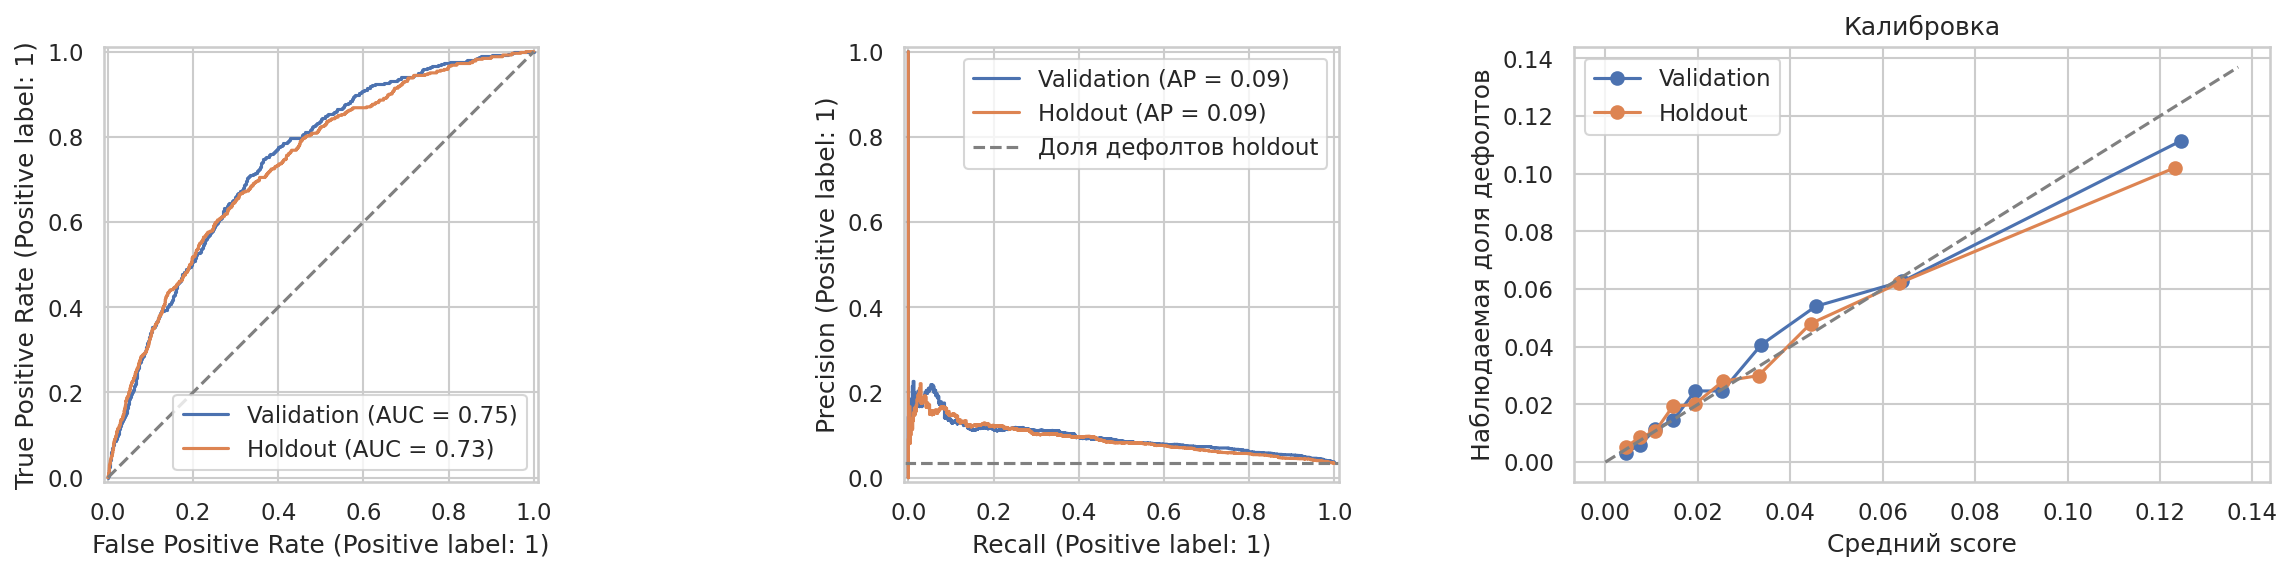

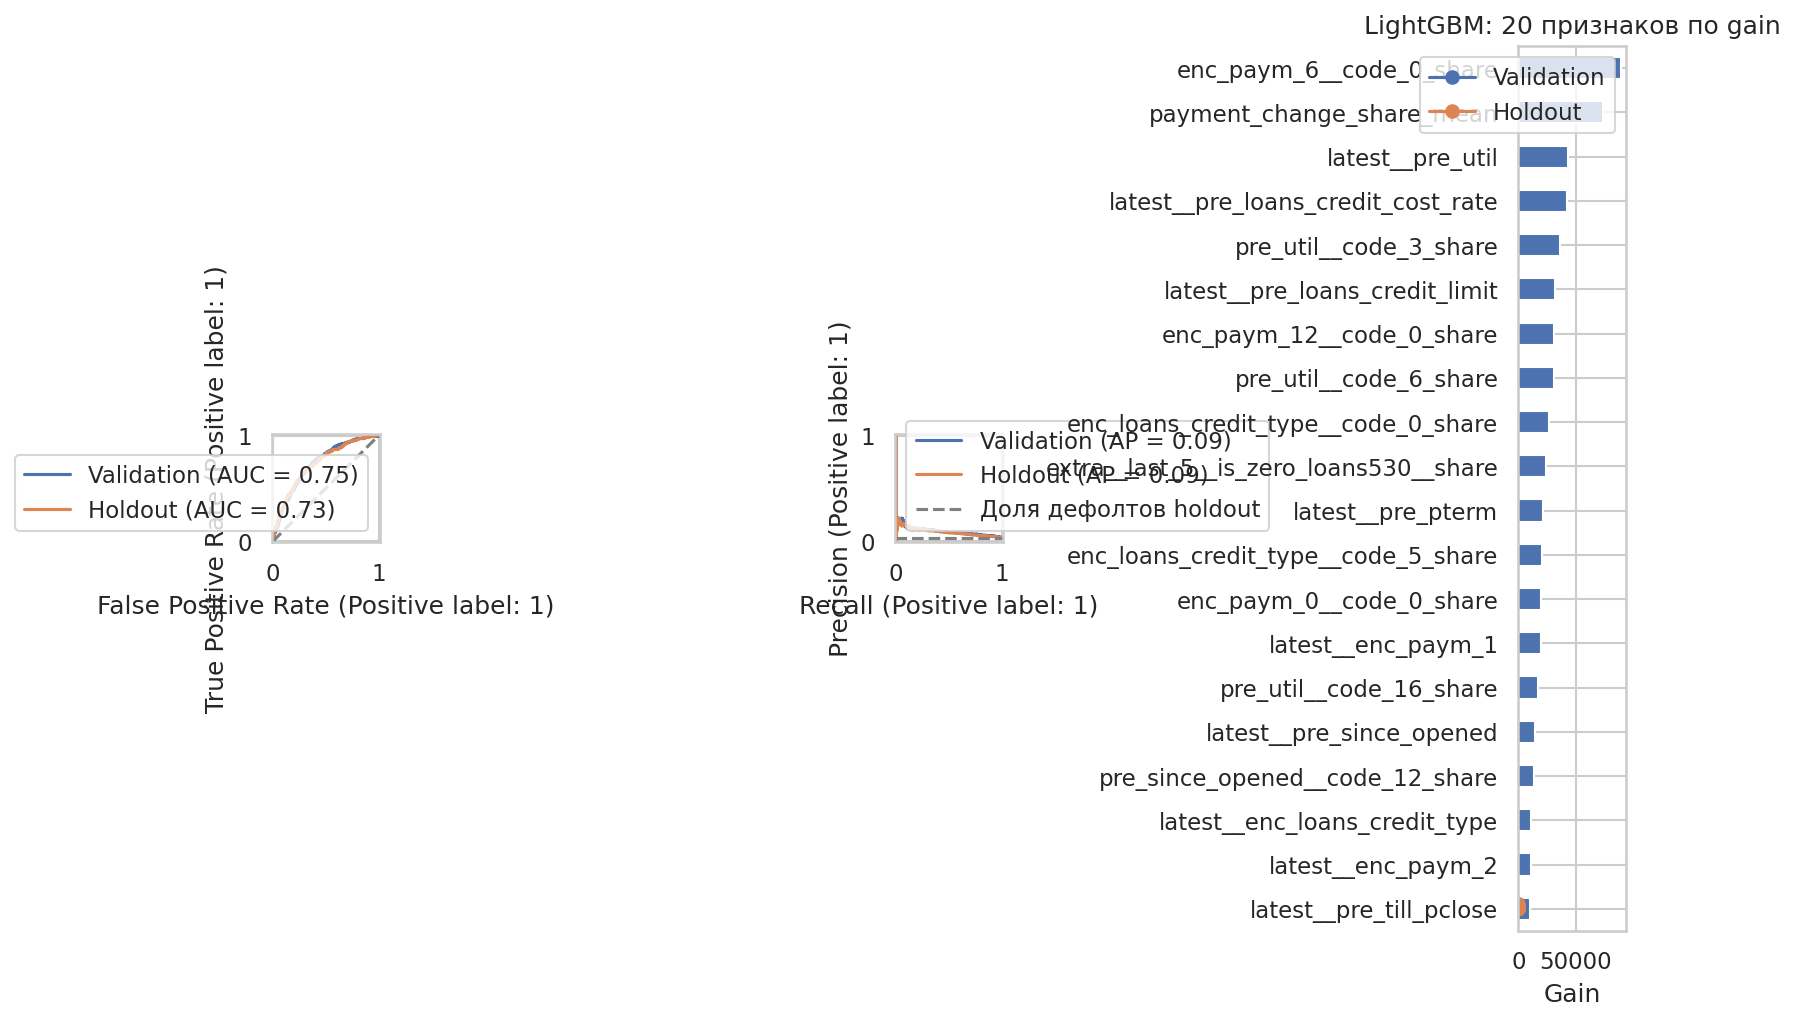

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
final_calibration_tables = []
for name, frame in [('Validation', final_valid), ('Holdout', final_holdout)]:
    RocCurveDisplay.from_predictions(frame.flag, frame.model_probability, ax=axes[0], name=name)
    PrecisionRecallDisplay.from_predictions(frame.flag, frame.model_probability, ax=axes[1], name=name)
    bins = pd.DataFrame({'bin': pd.qcut(frame.model_probability, 10, duplicates='drop'),
                         'score': frame.model_probability, 'flag': frame.flag})
    calibration = bins.groupby('bin', observed=True).agg(clients=('flag', 'size'),
        defaults=('flag', 'sum'), mean_probability=('score', 'mean'), observed_rate=('flag', 'mean')).reset_index()
    calibration['split'] = name
    final_calibration_tables.append(calibration)
    axes[2].plot(calibration.mean_probability, calibration.observed_rate, marker='o', label=name)
axes[0].plot([0, 1], [0, 1], '--', color='gray')
axes[1].axhline(final_holdout.flag.mean(), linestyle='--', color='gray', label='Доля дефолтов holdout')
axes[1].legend()
final_calibration = pd.concat(final_calibration_tables, ignore_index=True)
limit = final_calibration[['mean_probability', 'observed_rate']].to_numpy().max() * 1.1
axes[2].plot([0, limit], [0, limit], '--', color='gray')
axes[2].set(title='Калибровка', xlabel='Средний score', ylabel='Наблюдаемая доля дефолтов')
axes[2].legend()
plt.tight_layout()
fig.savefig(FINAL_REPORT_DIR / 'lightgbm_final_curves.png', dpi=150, bbox_inches='tight')
plt.show()
final_calibration.to_csv(FINAL_REPORT_DIR / 'calibration_bins.csv', index=False)

# Важность gain описывает использование признаков деревьями, не причинный эффект.
final_importance = pd.DataFrame({'feature': final_booster.feature_name(),
                                'gain': final_booster.feature_importance(importance_type='gain')})
final_importance.sort_values('gain', ascending=False).to_csv(FINAL_REPORT_DIR / 'feature_importance.csv', index=False)
ax = final_importance.nlargest(20, 'gain').sort_values('gain').set_index('feature').gain.plot.barh(figsize=(10, 7))
ax.set(title='LightGBM: 20 признаков по gain', xlabel='Gain', ylabel='')
plt.tight_layout()
ax.figure.savefig(FINAL_REPORT_DIR / 'feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 21. Выводы и ограничения

Зафиксированный результат holdout: **ROC-AUC 0,7344, AP 0,0896**. При пороге 0,05323 одобрено 80,65% заявок; среди них доля `flag=1` составляет **2,15% против 3,34%** во всей выборке — относительное снижение примерно на 36%. Среди отказов оказались **241 из 501 событий (48,1%)** и 2662 клиента без события. Более высокий охват требует большего числа отказов: это компромисс политики.

Приблизительный 95% bootstrap-интервал AUC на holdout: **0,7173–0,7575**; охвата событий — **44,1–52,4%**. Интервалы из выполненной проверки основаны на IID-перевыборке заявок и не учитывают возможную зависимость нескольких заявок одного клиента. Снижение AUC относительно validation около 0,0107; это не доказательство отсутствия временного сдвига.

LightGBM выбран как итоговое решение по достигнутому качеству и времени обучения. Полное сравнение с CatBoost на том же train оставляем на будущее. Горизонт и определение метки остаются ограничением данных. Нет информации для расчёта реальной прибыли и оценки поведения отклонённых клиентов. Validation использовалась в экспериментах, holdout после проверки открыт.

Для применения нужны файлы из папки `model`: деревья, схема, построитель признаков, словарь и код инференса. Старый `prepared_v2` сам по себе не является полным входом итоговой модели. Обучение воспроизводится отдельным `train_lightgbm.ipynb`; в этом блокноте оформлен результат и применение.

In [27]:
final_report = '# Итоговый кредитный скоринг: LightGBM\n\n'
final_report += '## Семейства: общая validation, разный объём train\n\n'
final_report += '```\n' + final_comparison.to_string() + '\n```\n\n'
final_report += '## Итоговый LightGBM: validation / holdout\n\n'
final_report += '```\n' + final_metrics.to_string() + '\n```\n\n'
final_report += 'Порог зафиксирован до открытия holdout: ' + str(FINAL_THRESHOLD) + '.\n'
final_report += 'Метрики baseline пересчитаны из сохранённых прогнозов; финальный LightGBM загружен из model.txt.\n'
final_report += 'Горизонт flag не подтверждён архивом. Holdout уже открыт. Нового обучения нет.\n'
(FINAL_REPORT_DIR / 'summary.md').write_text(final_report, encoding='utf-8')
with open(FINAL_REPORT_DIR / 'evaluation.json', 'w', encoding='utf-8') as file:
    json.dump({'model_directory': str(FINAL_MODEL_DIR), 'threshold': FINAL_THRESHOLD,
               'holdout_evaluated': True, 'new_training': False,
               'metrics': final_metrics.to_dict(), 'target': final_metadata['target']},
              file, ensure_ascii=False, indent=2)
print('Отчёт и графики:', FINAL_REPORT_DIR)

Отчёт и графики: credit-scoring/reports/generated
